# Binary Classification

Let's solve this problem: 2D points $(x, y)$ with label 1, if inside the circle $x^2 + y^2 < 1$ else 0. We shall solve this problem in Pytorch for wase of implementation.

In [ ]:
import torch
import random
import copy

import numpy as np
import matplotlib.pyplot as plt

import micrograd.nn as nn
from micrograd.engine import Value
import micrograd

from utils import generate_data, SGD, momentum, rmsprop, adam, tanhValue, sineValue
from train import simple_train

In [ ]:
# 1. Generate data and split it into train, test and validation set

# set random seed
np.random.seed(42)

# Let's generate random 2D points
n = 1000
data = (torch.rand(n, 2) * 2 - 1)*2 #torch.rand(n, 2) only creates random numbers in Q1, shift them to all Q's

# lets generate ground truth labels
mag = torch.sqrt(data[:, 0]**2 + data[:, 1]**2)
labels = (mag > 1.0).float()

dataset = torch.utils.data.TensorDataset(data, labels)

train_set, test_set, val_set = torch.utils.data.random_split(
    dataset, [600, 200, 200], generator=torch.Generator().manual_seed(42)
)

x_train, y_train = train_set[:][0], train_set[:][1].view(-1, 1)  # or iterate
x_test, y_test = test_set[:][0], test_set[:][1].view(-1, 1)

In [ ]:
# 2 Let's construct the network in Pytorch

"""
Input to the network is: 2D vectors
Output is 1D scalar value : either 1 or 0

Network is 2 inputs: 3 neurons in hidden (first) layer, 3 in hidden (second) layer, and 1 neuron in output layer
"""

BinaryMLP = torch.nn.Sequential(
    torch.nn.Linear(2, 3),
    torch.nn.ReLU(),
    torch.nn.Linear(3, 3),
    torch.nn.ReLU(),
    torch.nn.Linear(3, 1)
)

# 3. define optimization algorithm and loss function type
optimizer = torch.optim.SGD(BinaryMLP.parameters(), lr=0.01)
criterion = torch.nn.BCEWithLogitsLoss()

# 4. Train the network:
n_epochs = 10000
for epoch in range(n_epochs):
    optimizer.zero_grad() # grad zeroing step (otherwise gradients accumulate: remember micrograd)
    y_pred = BinaryMLP(x_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

In [ ]:
# 5. Inference
# first tell torch that this is test data,, don't compute gradients for this
with torch.no_grad():
    y_pred = BinaryMLP(x_test)
    predicted_labels = (torch.sigmoid(y_pred) > 0.5).float()

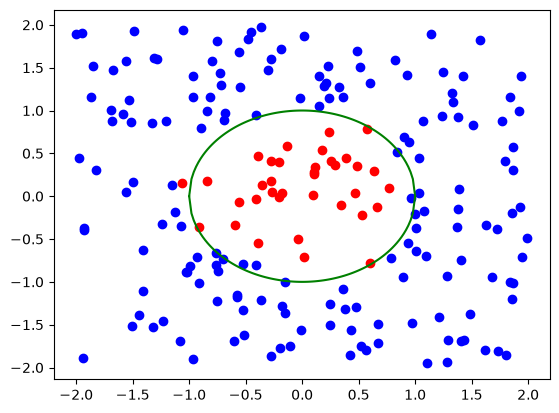

In [ ]:
# 6 plot
x_circle = np.linspace(-1, 1, 100)
y_circle= []
y_circle.extend([np.sqrt(1- x**2) for x in x_circle])
for i in range(len(x_test)):
    plt.scatter(x_test[i][0], x_test[i][1], 
                color='r' if predicted_labels[i].item() == 0 else "b")

plt.plot(x_circle, y_circle, color="g")
plt.plot(x_circle, [-1*y for y in y_circle], color="g")
